## WeGo Data Introduction

In [1]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
wego = pd.read_csv("data/Headway Data, 8-1-2023 to 9-30-2023.csv")

In [3]:
wego.columns

Index(['CALENDAR_ID', 'SERVICE_ABBR', 'ADHERENCE_ID', 'DATE', 'ROUTE_ABBR',
       'BLOCK_ABBR', 'OPERATOR', 'TRIP_ID', 'OVERLOAD_ID',
       'ROUTE_DIRECTION_NAME', 'TIME_POINT_ABBR', 'ROUTE_STOP_SEQUENCE',
       'TRIP_EDGE', 'LATITUDE', 'LONGITUDE', 'SCHEDULED_TIME',
       'ACTUAL_ARRIVAL_TIME', 'ACTUAL_DEPARTURE_TIME', 'ADHERENCE',
       'SCHEDULED_HDWY', 'ACTUAL_HDWY', 'HDWY_DEV', 'ADJUSTED_EARLY_COUNT',
       'ADJUSTED_LATE_COUNT', 'ADJUSTED_ONTIME_COUNT', 'STOP_CANCELLED',
       'PREV_SCHED_STOP_CANCELLED', 'IS_RELIEF', 'DWELL_IN_MINS',
       'SCHEDULED_LAYOVER_MINUTES'],
      dtype='object')

In the data, the bus route can be identified by its ROUTE_ABBR value.  
**3:** West End  
**7:** Hillsboro  
**22:** Bordeaux  
**23:** Dickerson Pike  
**50:** Charlotte Pike  
**52:** Nolensville Pike  
**55:** Murfreesboro Pike  
**56:** Gallatin Pike

The trip can be identified by the DATE/CALENDAR_ID plus the TRIP_ID.  
**Warning:** The TRIP_ID refers to the route and time but will be used across multiple days.

The data contains multiple **time points** for each trip. There are more stops along the route than time points, but the time points are the points with specific scheduled times the bus operators must adhere to.

The first stop of a trip has a TRIP_EDGE of 1, the last has a TRIP_EDGE of 2, and the intermediate stops are TRIP_EDGE 0. 

Here is the first trip in the dataset. It was a Bordeaux route (Route 22), scheduled to start at 4:42:00 and end at 5:10:00.

**Adherence** refers to the difference between scheduled time and the actual time that the bus departs from a stop.

A negative value for ADHERENCE indicates that the bus is late, and a positive indicates that the bus is early.

Generally, an adherence value less than -6 is considered late, and greater than 1 is considered early, but there are some exceptions. For example, a positive adherence for the end of a trip (TRIP_EDGE 2) is not considered early, since it is not a problem if a bus ends its trip early as long as it didn't pass other timepoints early along the way. You can check whether a trip was considered on-time, early, or late using the ADJUSTED_EARLY_COUNT, ADJUSTED_LATE_COUNT, and ADJUSTED_ONTIME_COUNT columns.

Here is an example of a trip where all time points would be considered to be on time. Notice that at the end of the trip, the bus was more than 6 minutes early, but was still counted as on-time since this was a trip edge of 2.

**Headway** is the amount of time between a bus and the prior bus at the same stop. In the dataset, the amount of headway scheduled is contained in the SCHEDULED_HDWY column and indicates the difference between the scheduled time for a particular stop and the scheduled time for the previous bus on that same stop.

This dataset contains a column HDWY_DEV, which shows the amount of deviation from the scheduled headway. **Bunching** occurs when there is shorter headway than scheduled, which would appear as a negative HDWY_DEV value. **Gapping** is when there is more headway than scheduled and appears as a positive value in the HDWY_DEV column. Note that you can calculate headway deviation percentage as HDWY_DEV/SCHEDULED_HDWY. 

The generally accepted range of headway deviation is 50% to 150% of the scheduled headway, so if scheduled headway is 10 minutes, a headway deviation of up to 5 minutes would be acceptable (but not ideal).

Two other columns that you've been asked to explore are the DWELL_IN_MINS column and SCHEDULED_LAYOVER_MINUTES, which shows the difference between actual arrival and actual departure time at a time point and the time a bus was scheduled to arrive at the time point and when it is scheduled to leave at the beginning of a trip.

Here, we can see the end of the first trip in the dataset and the beginning of the next trip, which goes in the opposite direction.

In [4]:
adhere=wego[['ADHERENCE']]
adhere=adhere.ADHERENCE.value_counts().to_frame().reset_index()
adhere

,ADHERENCE,count
0,0.966666,1355
1,0.950000,1341
2,-0.166666,1082
3,-0.200000,1042
4,-0.100000,1033
...,...,...
3760,-29.533333,1
3761,-166.566666,1
3762,-42.833333,1
3763,-39.550000,1


In [5]:
adhere=wego[['ADHERENCE']]
adhere=adhere.ADHERENCE.value_counts().to_frame().reset_index()
for ind, row in adhere.iterrows():
    if row['ADHERENCE']<-6:
        adhere.loc[ind,'TRUE_ADHERENCE']='Late'
    elif row['ADHERENCE']>1:
        adhere.loc[ind,'TRUE_ADHERENCE']='Early'
    else:
        adhere.loc[ind,'TRUE_ADHERENCE']='On Time'
adhere

,ADHERENCE,count,TRUE_ADHERENCE
0,0.966666,1355,On Time
1,0.950000,1341,On Time
2,-0.166666,1082,On Time
3,-0.200000,1042,On Time
4,-0.100000,1033,On Time
...,...,...,...
3760,-29.533333,1,Late
3761,-166.566666,1,Late
3762,-42.833333,1,Late
3763,-39.550000,1,Late


In [6]:
trueadhere=adhere.TRUE_ADHERENCE.value_counts()
trueadhere

TRUE_ADHERENCE
Late       2555
Early       789
On Time     421
Name: count, dtype: int64

## How does direction of travel, route, or location affect the on-time performance?

In [7]:
wego.ROUTE_DIRECTION_NAME.value_counts()

ROUTE_DIRECTION_NAME
FROM DOWNTOWN    185793
TO DOWNTOWN      164536
Name: count, dtype: int64

In [8]:
witchway=wego[['TRIP_ID', 'ADHERENCE','ROUTE_DIRECTION_NAME']]
for ind, row in witchway.iterrows():
    if row['ADHERENCE']<-6:
        witchway.loc[ind,'TRUE_ADHERENCE']='Late'
    elif row['ADHERENCE']>1:
        witchway.loc[ind,'TRUE_ADHERENCE']='Early'
    else:
        witchway.loc[ind,'TRUE_ADHERENCE']='On Time'
witchway.groupby(['TRUE_ADHERENCE','ROUTE_DIRECTION_NAME']).count().reset_index()
witchway

C:\Users\Owner\AppData\Local\Temp\ipykernel_12792\1031890915.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  witchway.loc[ind,'TRUE_ADHERENCE']='On Time'


,TRIP_ID,ADHERENCE,ROUTE_DIRECTION_NAME,TRUE_ADHERENCE
0,345104,-2.133333,TO DOWNTOWN,On Time
1,345104,-2.450000,TO DOWNTOWN,On Time
2,345104,-0.933333,TO DOWNTOWN,On Time
3,345104,6.283333,TO DOWNTOWN,Early
4,345105,-1.583333,FROM DOWNTOWN,On Time
...,...,...,...,...
350324,353448,-8.433333,TO DOWNTOWN,Late
350325,353448,-11.300000,TO DOWNTOWN,Late
350326,353449,-4.316666,FROM DOWNTOWN,On Time
350327,353449,-22.083333,FROM DOWNTOWN,Late


In [9]:
witchroute=wego[['TRIP_ID', 'ADHERENCE','ROUTE_ABBR']]
for ind, row in witchroute.iterrows():
    if row['ADHERENCE']<-6:
        witchroute.loc[ind,'TRUE_ADHERENCE']='Late'
    elif row['ADHERENCE']>1:
        witchroute.loc[ind,'TRUE_ADHERENCE']='Early'
    else:
        witchroute.loc[ind,'TRUE_ADHERENCE']='On Time'
witchroute

C:\Users\Owner\AppData\Local\Temp\ipykernel_12792\3650360516.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  witchroute.loc[ind,'TRUE_ADHERENCE']='On Time'


,TRIP_ID,ADHERENCE,ROUTE_ABBR,TRUE_ADHERENCE
0,345104,-2.133333,22,On Time
1,345104,-2.450000,22,On Time
2,345104,-0.933333,22,On Time
3,345104,6.283333,22,Early
4,345105,-1.583333,22,On Time
...,...,...,...,...
350324,353448,-8.433333,7,Late
350325,353448,-11.300000,7,Late
350326,353449,-4.316666,7,On Time
350327,353449,-22.083333,7,Late


In [10]:
route_results=witchroute.groupby(['TRUE_ADHERENCE','ROUTE_ABBR']).count().reset_index()
route_results

,TRUE_ADHERENCE,ROUTE_ABBR,TRIP_ID,ADHERENCE
0,Early,3,3185,3185
1,Early,7,1782,1782
2,Early,22,5075,5075
3,Early,23,5621,5621
4,Early,50,4106,4106
5,Early,52,3549,3549
6,Early,55,3794,3794
7,Early,56,5920,5920
8,Late,3,9590,9590
9,Late,7,3417,3417


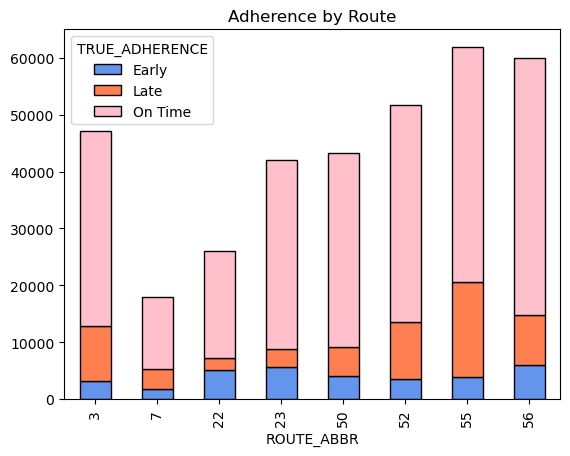

In [18]:
pd.crosstab(  index= route_results['ROUTE_ABBR'], 
    columns= route_results['TRUE_ADHERENCE'],
    values= route_results['TRIP_ID'],
    aggfunc='sum').plot(kind = 'bar', 
                                                          stacked = True,       # stacked as opposed to side-by-side
                                                          color = ['cornflowerblue', 'coral', 'pink'],     # change the default colors
                                                          edgecolor = 'black')              # add a border to the bars
plt.title('Adherence by Route')
plt.savefig('../witch route.png', bbox_inches='tight', pad_inches=0.1)

In [12]:
witchplace=wego[['TRIP_ID', 'ADHERENCE','BLOCK_ABBR']]
for ind, row in witchplace.iterrows():
    if row['ADHERENCE']<-6:
        witchplace.loc[ind,'TRUE_ADHERENCE']='Late'
    elif row['ADHERENCE']>1:
        witchplace.loc[ind,'TRUE_ADHERENCE']='Early'
    else:
        witchplace.loc[ind,'TRUE_ADHERENCE']='On Time'
witchplace=witchplace.groupby(['TRUE_ADHERENCE','BLOCK_ABBR']).count().reset_index()
witchplace

C:\Users\Owner\AppData\Local\Temp\ipykernel_12792\3215087791.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  witchplace.loc[ind,'TRUE_ADHERENCE']='On Time'


,TRUE_ADHERENCE,BLOCK_ABBR,TRIP_ID,ADHERENCE
0,Early,300,663,663
1,Early,301,447,447
2,Early,302,77,77
3,Early,303,148,148
4,Early,304,41,41
...,...,...,...,...
300,On Time,8601,45,31
301,On Time,8604,35,35
302,On Time,9302,50,50
303,On Time,9950,42,37


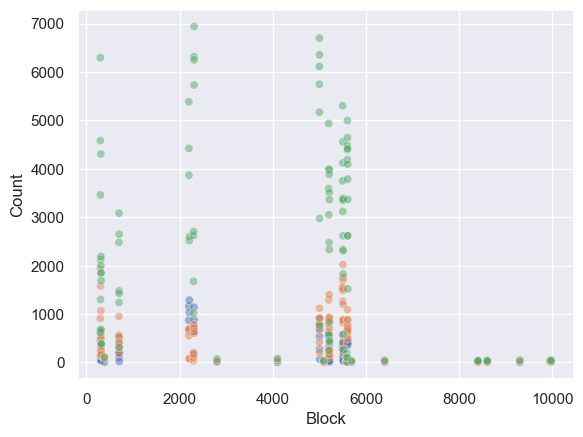

In [39]:
sns.set_theme(style="darkgrid")
witchgraph= sns.scatterplot(
    data=witchplace,
    x="BLOCK_ABBR",
    y="TRIP_ID",
   # size="TRIP_ID",
    legend=False,
    hue="TRUE_ADHERENCE",
    alpha=0.5,
    sizes=(20, 400),
)
witchgraph.set_ylabel("Count")
witchgraph.set_xlabel("Block")
plt.savefig('../Filename.png', bbox_inches='tight', pad_inches=0.1)

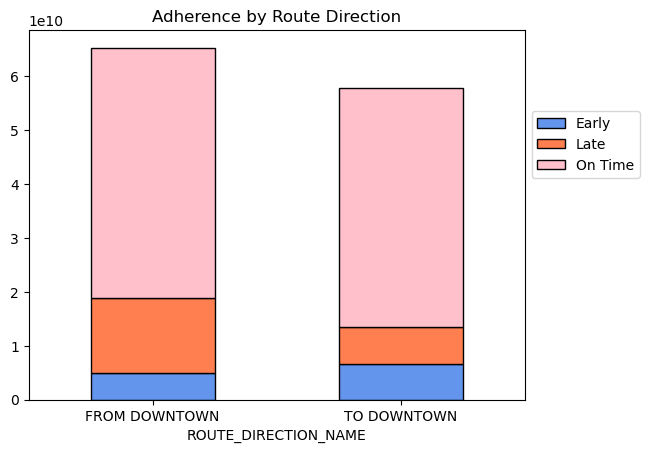

In [21]:
pd.crosstab(  index= witchway['ROUTE_DIRECTION_NAME'], 
    columns= witchway['TRUE_ADHERENCE'],
    values= witchway['TRIP_ID'],
    aggfunc='sum').plot(kind = 'bar', 
                                                          stacked = True,       # stacked as opposed to side-by-side
                                                          color = ['cornflowerblue', 'coral', 'pink'],     # change the default colors
                                                          edgecolor = 'black')              # add a border to the bars
plt.title('Adherence by Route Direction')
plt.legend(bbox_to_anchor = (1, 0.8), loc = 'upper left')
plt.xticks(rotation=0) 
